# Continuous-Time Quantum Walk in Photosynthetic Energy Transfer

In [1]:
!pip install -qq "classiq[chemistry]"

In [1]:
import time
from functools import reduce
from operator import mul

import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import expm

from classiq import *

## Continuous-Time Quantum Walk on a graph

Let $G(V, E)$ be a graph where $V$ is the vertex set and $E$ is the edge set, with $N$ representing the number of vertices ($|V| = N$).
In this model, a walker diffuses across the vertices of the graph via its edges. The distribution of the walker is represented as a wavefunction $|\psi(t)\rangle$ in an $N$-dimensional Hilbert space spanned by the basis $\{|0\rangle, |1\rangle, \dots, |N-1\rangle\}$. The probability of finding the walker at vertex $v_j \in V$ is given by:
$$
p_j = \left|\langle j|\psi(t)\rangle\right|^2
$$

Given an initial state $|\psi(0)\rangle$, the time evolution of the continuous-time quantum walk is determined by:
$$
|\psi(t)\rangle = e^{-iHt} |\psi(0)\rangle
$$
Here, the Hamiltonian $H$ is defined using the adjacency matrix $A$ of the graph as $H = -\gamma A$, where $\gamma > 0$ is a constant representing the transmission rate of the walker [[1](#Portugal2025)].


## Frenkel exciton Hamiltonian

$$
\def\H{\hat{H}}
\def\x{\hat{x}}
\def\p{\hat{p}}
\def\bin{\operatorname{bin}}
\def\a{\hat{a}}
\def\aD{\hat{a}^\dagger}
$$

Photosynthesis is the process by which plants use light energy to synthesize organic compounds from carbon dioxide and water.
During this process, pigment-protein complexes known as light-harvesting complexes absorb light energy or receive it from other complexes, transporting this excitation energy to a reaction center.
The most critical aspect of this process is the energy transfer mechanism.
It is experimentally known that quantum interference plays a role in this mechanism, and one of the light-harvesting complexes where such phenomena have been observed is the Fenna-Matthews-Olson (FMO) complex [[2](#Mohseni2008)].

The FMO complex has a trimeric structure, with each subunit containing eight Bacteriochlorophyll (BChl) *a* pigments. 
Seven of these are strongly bound within the protein scaffold and interact with each other due to their arrangement within the scaffold [[3](#Maiuri2018)]. It is well established that the optical spectra of the FMO complex are primarily determined by the interactions within a single subunit [[4](#Cho2005)].

Let us describe the movement of these excitations through Hamiltonian time evolution.
Consider the ground state of the system as $|\psi_0\rangle$ and the excited state localized on a single pigment (a Frenkel exciton) as $|m\rangle = \aD_m |\psi_0\rangle$.
In this framework, the Frenkel exciton Hamiltonian for the FMO complex is defined as follows:
$$
H = \sum_{m=1}^N \varepsilon_m \aD_m \a_m + \sum_{n < m}^N J_{mn} (\aD_m \a_n + \aD_n \a_m),
$$
where $\aD_m$ and $\a_m$ are the creation and annihilation operators for electronic excitation at the $m$-th pigment, $N$ is the number of pigments, $\varepsilon_m$ is the site energy of pigment $m$, $J_{mn}$ is the coupling constant between pigments $m$ and $n$.

In this notebook, we will perform a continuous-time quantum walk using the Frenkel exciton Hamiltonian given in [[4](#Cho2005)].

In [2]:
fmo_hamiltonian = np.array(
    [
        [280, -106, 8, -5, 6, -8, -4],
        [-106, 420, 28, 6, 2, 13, 1],
        [8, 28, 0, -62, -1, -9, 17],
        [-5, 6, -62, 175, -70, -19, -57],
        [6, 2, -1, -70, 320, 40, -2],
        [-8, 13, -9, -19, 40, 360, 32],
        [-4, 1, 17, -57, -2, 32, 260],
    ],
    dtype=float,
)  # unit: cm^-1

The aforementioned Hamiltonian can also be written as follows:
$$
H = \sum_{m=1}^N \varepsilon_m |m\rangle\langle m| + \sum_{n < m}^N J_{mn} (|m\rangle\langle n| + |n\rangle\langle m|)
$$
To handle this Hamiltonian on a quantum computer, we must express it as a sum of Pauli strings. First, to map the qubit states to each site's basis, we represent the integers from $0$ to $N-1$ in binary notation as follows:
$$
|m\rangle = |m_{L-1}\rangle \otimes \cdots \otimes |m_1\rangle \otimes |m_0\rangle
$$
Where $m_i \in \{0, 1\}$, and $L = \lceil \log_2 N\rceil$ is the number of qubits required to represent the integers from $0$ to $N-1$ in binary. In this representation, the projection operators appearing in the Hamiltonian are given by:
$$
|m\rangle\langle n| = |m_{L-1}\rangle\langle n_{L-1}| \otimes \cdots \otimes |m_1\rangle\langle n_1| \otimes |m_0\rangle\langle n_0|
$$
Consequently, the Hamiltonian can be expressed as a sum of Pauli strings using the following transformations:
$$
\begin{equation*}
\begin{split}
|0\rangle\langle 0| & = \frac{1}{2}(I + Z),\\
|1\rangle\langle 0| & = \frac{1}{2}(X - iY),\\
\end{split}
\qquad
\begin{split}
|1\rangle\langle 1| & = \frac{1}{2}(I - Z),\\
|0\rangle\langle 1| & = \frac{1}{2}(X + iY).\\
\end{split}
\end{equation*}
$$
Note that the Frenkel exciton Hamiltonian restricts the excitation to the single-exciton manifold, so it is not scalable. However, for a better description of energy-transfer dynamics, we need to mix single-exciton states with ground state or multiexciton states, and in this case, the computational complexity scales exponentially with the number of pigments [[5](#Lee2022)].

In [3]:
def create_projector(ket: int, bra: int, qubits: list[int]) -> SparsePauliOp:
    """Create projector operator for given ket and bra states.

    Args:
        ket (int): Ket state.
        bra (int): Bra state.
        qubits (list[int]): List of qubit indices.

    Returns:
        SparsePauliOp: Projector operator.
    """
    m = len(qubits)
    if not (0 <= ket < 2**m and 0 <= bra < 2**m):
        raise ValueError("Ket and bra states must be in the range [0, 2^m).")
    ket_bin = bin(ket)[2:].zfill(m)
    bra_bin = bin(bra)[2:].zfill(m)
    paulis_coeffs = []
    for i in range(m):
        if ket_bin[i] == "0" and bra_bin[i] == "0":
            paulis_coeffs.append((Pauli.I(qubits[i]) + Pauli.Z(qubits[i])) / 2)
        elif ket_bin[i] == "0" and bra_bin[i] == "1":
            paulis_coeffs.append((Pauli.X(qubits[i]) + 1j * Pauli.Y(qubits[i])) / 2)
        elif ket_bin[i] == "1" and bra_bin[i] == "0":
            paulis_coeffs.append((Pauli.X(qubits[i]) - 1j * Pauli.Y(qubits[i])) / 2)
        elif ket_bin[i] == "1" and bra_bin[i] == "1":
            paulis_coeffs.append((Pauli.I(qubits[i]) - Pauli.Z(qubits[i])) / 2)

    return reduce(mul, paulis_coeffs)


print(create_projector(2, 3, [0, 1]))  # |2><3|

-0.25*Pauli.Z(0)*Pauli.X(1) + (-0-0.25j)*Pauli.Z(0)*Pauli.Y(1) + 0.25*Pauli.X(1) + 0.25j*Pauli.Y(1)


In [4]:
fmo_hamiltonian_sparse = []
for i in range(fmo_hamiltonian.shape[0]):
    for j in range(fmo_hamiltonian.shape[1]):
        fmo_hamiltonian_sparse.append(
            create_projector(i, j, list(range(3))) * fmo_hamiltonian[i, j]
        )
fmo_hamiltonian_sparse = reduce(lambda x, y: x + y, fmo_hamiltonian_sparse)

To approximate the time evolution of the constructed Hamiltonian, we employ the first-order Suzuki-Trotter decomposition:
$$
\begin{equation*}
e^{-itH}=\exp\left\{-it\sum_{j=1}^N h_j H_j\right\} \approx \left(\prod_{j}^N e^{-it h_j H_j/r}\right)^r.
\end{equation*}
$$
Here, we fix the number of time slices $r = 10$.

In [5]:
@qfunc
def main(qnum: Output[QNum], time_point: CReal):
    allocate(3, qnum)
    suzuki_trotter(
        fmo_hamiltonian_sparse,
        evolution_coefficient=time_point,
        order=1,
        repetitions=10,
        qbv=qnum,
    )


qprog = synthesize(main)
qprog = set_quantum_program_execution_preferences(
    qprog,
    preferences=ExecutionPreferences(
        num_shots=1,
        backend_preferences=ClassiqBackendPreferences(
            backend_name="simulator_statevector"
        ),
    ),
)
show(qprog)

Quantum program link: https://platform.classiq.io/circuit/3AfodhCYvcGlhUz4OszGb8GO5SM


In [6]:
time_points = np.linspace(0, 0.1, 20)
trotter_results = []
durations = []

with ExecutionSession(qprog) as es:
    for time_point in time_points:
        time1 = time.time()

        result = es.sample({"time_point": time_point})

        probs = [0.0] * 2**3

        for detail in result.parsed_state_vector:
            probs[detail.state["qnum"]] = abs(detail.amplitude) ** 2

        trotter_results.append(probs)
        time2 = time.time()
        duration = time2 - time1
        durations.append(duration)
        print(f"Time point: {time_point:.4f}, Duration: {duration:.4f} seconds")

Time point: 0.0000, Duration: 3.1757 seconds
Time point: 0.0053, Duration: 1.4201 seconds
Time point: 0.0105, Duration: 1.1634 seconds
Time point: 0.0158, Duration: 1.5226 seconds
Time point: 0.0211, Duration: 1.3114 seconds
Time point: 0.0263, Duration: 1.3861 seconds
Time point: 0.0316, Duration: 1.4072 seconds
Time point: 0.0368, Duration: 1.5634 seconds
Time point: 0.0421, Duration: 1.3170 seconds
Time point: 0.0474, Duration: 1.8323 seconds
Time point: 0.0526, Duration: 1.4475 seconds
Time point: 0.0579, Duration: 2.8823 seconds
Time point: 0.0632, Duration: 1.4217 seconds
Time point: 0.0684, Duration: 1.3346 seconds
Time point: 0.0737, Duration: 1.3152 seconds
Time point: 0.0789, Duration: 1.3476 seconds
Time point: 0.0842, Duration: 1.2203 seconds
Time point: 0.0895, Duration: 1.1928 seconds
Time point: 0.0947, Duration: 1.5286 seconds
Time point: 0.1000, Duration: 1.3296 seconds


Let's compare the calculation results with those obtained using `scipy`.

Here, we plot the time evolution of the exciton population for pigments 0, 1, and 2.
We see that accuracy decreases over time due to decomposition error.

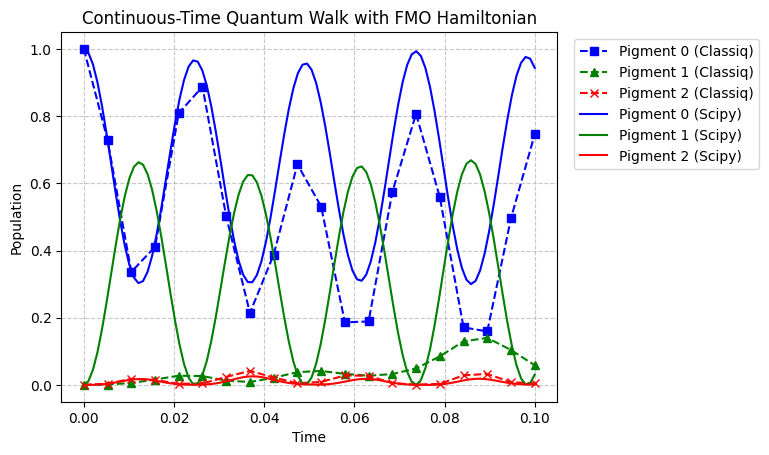

In [7]:
def simulate_ctqw(time_steps, initial_node=0):
    H = fmo_hamiltonian

    # initial state
    psi0 = np.zeros(fmo_hamiltonian.shape[0], dtype=complex)
    psi0[initial_node] = 1.0

    results = []
    for t in time_steps:
        # time evolution operator: U = exp(-i * H * t)
        U = expm(-1j * H * t)
        psi_t = np.dot(U, psi0)

        # 存在確率 |psi|^2 を計算
        probability = np.abs(psi_t) ** 2
        results.append(probability.tolist())

    return results


t_max = 0.1
time_steps = np.linspace(0, t_max, 100)

probs = simulate_ctqw(time_steps, initial_node=0)

plt.plot(
    time_points, [p[0] for p in trotter_results], "bs--", label="Pigment 0 (Classiq)"
)
plt.plot(
    time_points, [p[1] for p in trotter_results], "g^--", label="Pigment 1 (Classiq)"
)
plt.plot(
    time_points, [p[2] for p in trotter_results], "rx--", label="Pigment 2 (Classiq)"
)

plt.plot(time_steps, [p[0] for p in probs], "b-", label="Pigment 0 (Scipy)")
plt.plot(time_steps, [p[1] for p in probs], "g-", label="Pigment 1 (Scipy)")
plt.plot(time_steps, [p[2] for p in probs], "r-", label="Pigment 2 (Scipy)")
plt.title("Continuous-Time Quantum Walk with FMO Hamiltonian")
plt.xlabel("Time")
plt.ylabel("Population")
plt.legend(bbox_to_anchor=(1.02, 1))
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

## References

<a id='Portugal2025'>[1]</a>: [R. Portugal and J. K. Moqadam, Efficient circuit implementations of continuous-time quantum walks for quantum search, Entropy (Basel) 27, 454 (2025).](https://www.mdpi.com/1099-4300/27/5/454)

<a id='Mohseni2008'>[2]</a>: [M. Mohseni, P. Rebentrost, S. Lloyd, and A. Aspuru-Guzik, Environment-assisted quantum walks in photosynthetic energy transfer, J. Chem. Phys. 129, 174106 (2008).](https://doi.org/10.1063/1.3002335)

<a id='Maiuri2018'>[3]</a>: [M. Maiuri, E. E. Ostroumov, R. G. Saer, R. E. Blankenship, and G. D. Scholes, Coherent wavepackets in the Fenna-Matthews-Olson complex are robust to excitonic-structure perturbations caused by mutagenesis, Nat. Chem. 10, 177 (2018).](https://doi.org/10.1038/nchem.2910)

<a id='Cho2005'>[4]</a>: [M. Cho, H. M. Vaswani, T. Brixner, J. Stenger, and G. R. Fleming, Exciton analysis in 2D electronic spectroscopy, J. Phys. Chem. B 109, 10542 (2005).](https://doi.org/10.1021/jp050788d)

<a id='Lee2022'>[5]</a>: [C.-K. Lee, J. W. Zhong Lau, L. Shi, and L. C. Kwek, Simulating energy transfer in molecular systems with digital quantum computers, J. Chem. Theory Comput. 18, 1347 (2022).](https://doi.org/10.1021/acs.jctc.1c01296)
